In [ ]:
# ── Install extra packages not pre-installed in Colab ──
!pip install -q shap xgboost lightgbm ipywidgets
print('✅ Packages ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.5 MB/s eta 0:00:00
✅ Packages ready


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

# Boosting
from xgboost import XGBRegressor
import lightgbm as lgb

# SHAP
import shap
shap.initjs()  # enables interactive JS plots in Colab

# Interactive widgets
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0b0',
    'ytick.color':      '#a0a0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

ACCENT   = '#00d4ff'
ACCENT2  = '#ff6b6b'
ACCENT3  = '#ffd93d'
PALETTE  = [ACCENT, ACCENT2, ACCENT3, '#6bcb77', '#c77dff']
SEED     = 42

print('✅ All imports successful')

✅ All imports successful


In [ ]:
# ── Load dataset ──
# Option A: built-in sklearn (recommended for Colab — no file upload needed)
raw = fetch_california_housing(as_frame=True)
df  = raw.frame.copy()
df.rename(columns={'MedHouseVal': 'median_house_value'}, inplace=True)

# Option B: load your own CSV  ← uncomment if you have a file
# from google.colab import files
# uploaded = files.upload()            # choose Californiahousing.csv
# df = pd.read_csv(list(uploaded.keys())[0])
# df.columns = df.columns.str.lower().str.replace(' ','_')
# df.rename(columns={'medhouval':'median_house_value'}, inplace=True)

TARGET = 'median_house_value'
print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# ── Basic stats ──
display(HTML('<h4 style="color:#00d4ff">Descriptive Statistics</h4>'))
display(df.describe().style
    .background_gradient(cmap='Blues', axis=0)
    .format('{:.3f}')
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [ ]:
# ── Missing values & dtypes ──
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else '  None! Clean dataset ✅')
print(f'\nDtypes:\n{df.dtypes}')

Missing values per column:
  None! Clean dataset ✅

Dtypes:
MedInc                float64
HouseAge              float64
AveRooms              float64
AveBedrms             float64
Population            float64
AveOccup              float64
Latitude              float64
Longitude             float64
median_house_value    float64
dtype: object


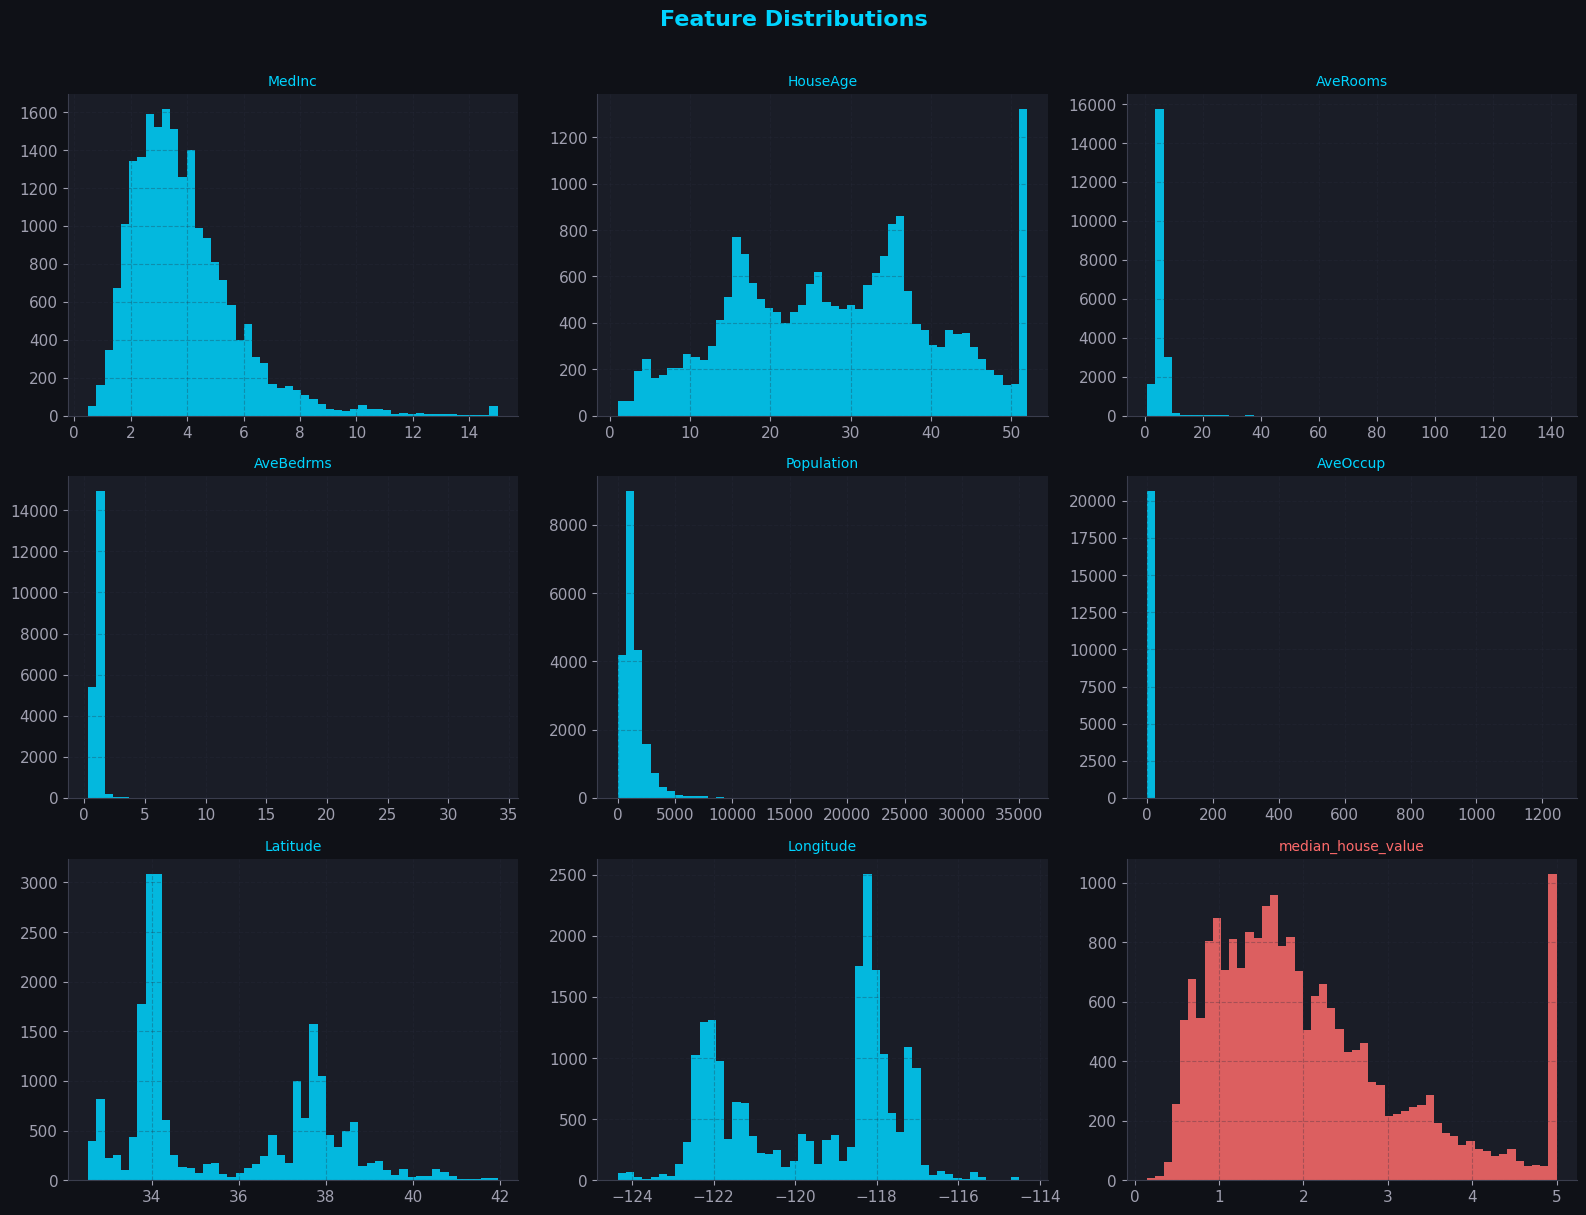

In [ ]:
# ── Distribution plots ──
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold', color=ACCENT, y=1.01)

for ax, col in zip(axes.flat, df.columns):
    color = ACCENT if col != TARGET else ACCENT2
    ax.hist(df[col], bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(col, color=color, fontsize=10)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

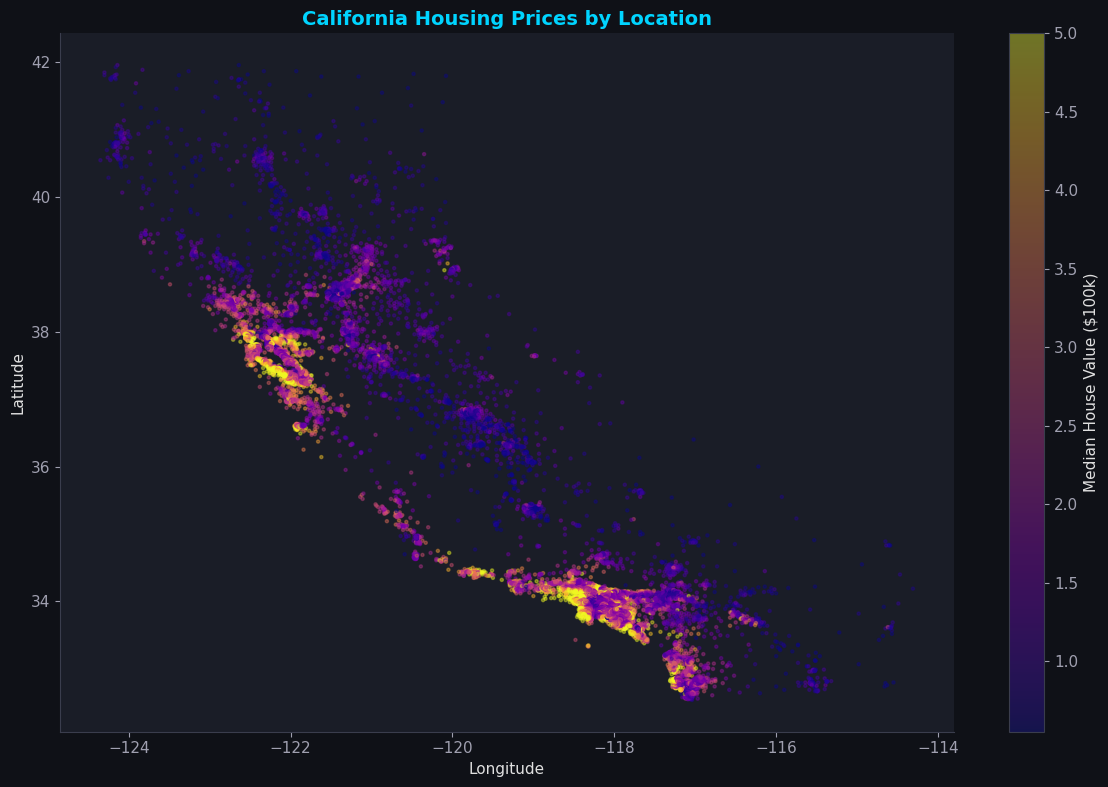

In [ ]:
# ── Geographic scatter ──
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    df['Longitude'], df['Latitude'],
    c=df[TARGET], cmap='plasma',
    alpha=0.4, s=5, vmin=df[TARGET].quantile(0.02), vmax=df[TARGET].quantile(0.98)
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Median House Value ($100k)', color='#e0e0e0')
ax.set_title('California Housing Prices by Location', fontsize=14, color=ACCENT, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [ ]:
def engineer_features(df_in):
    df = df_in.copy()

    # Derived ratios
    df['rooms_per_household']      = df['AveRooms']   # already per household in sklearn dataset
    df['bedrooms_per_room']        = df['AveBedrms'] / df['AveRooms'].replace(0, np.nan)
    df['population_per_household'] = df['Population'] / df['HouseAge'].replace(0, np.nan)  # proxy
    df['income_x_rooms']           = df['MedInc'] * df['AveRooms']
    df['location_cluster']         = (df['Latitude'] * df['Longitude']).abs()
    df['age_income_ratio']         = df['HouseAge'] / (df['MedInc'] + 1)

    # Log transforms for skewed features
    for col in ['Population', 'AveOccup']:
        df[f'log_{col}'] = np.log1p(df[col])

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)
    return df

df = engineer_features(df)

FEATURE_COLS = [c for c in df.columns if c != TARGET]
print(f'Features after engineering: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Features after engineering: 16
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_x_rooms', 'location_cluster', 'age_income_ratio', 'log_Population', 'log_AveOccup']


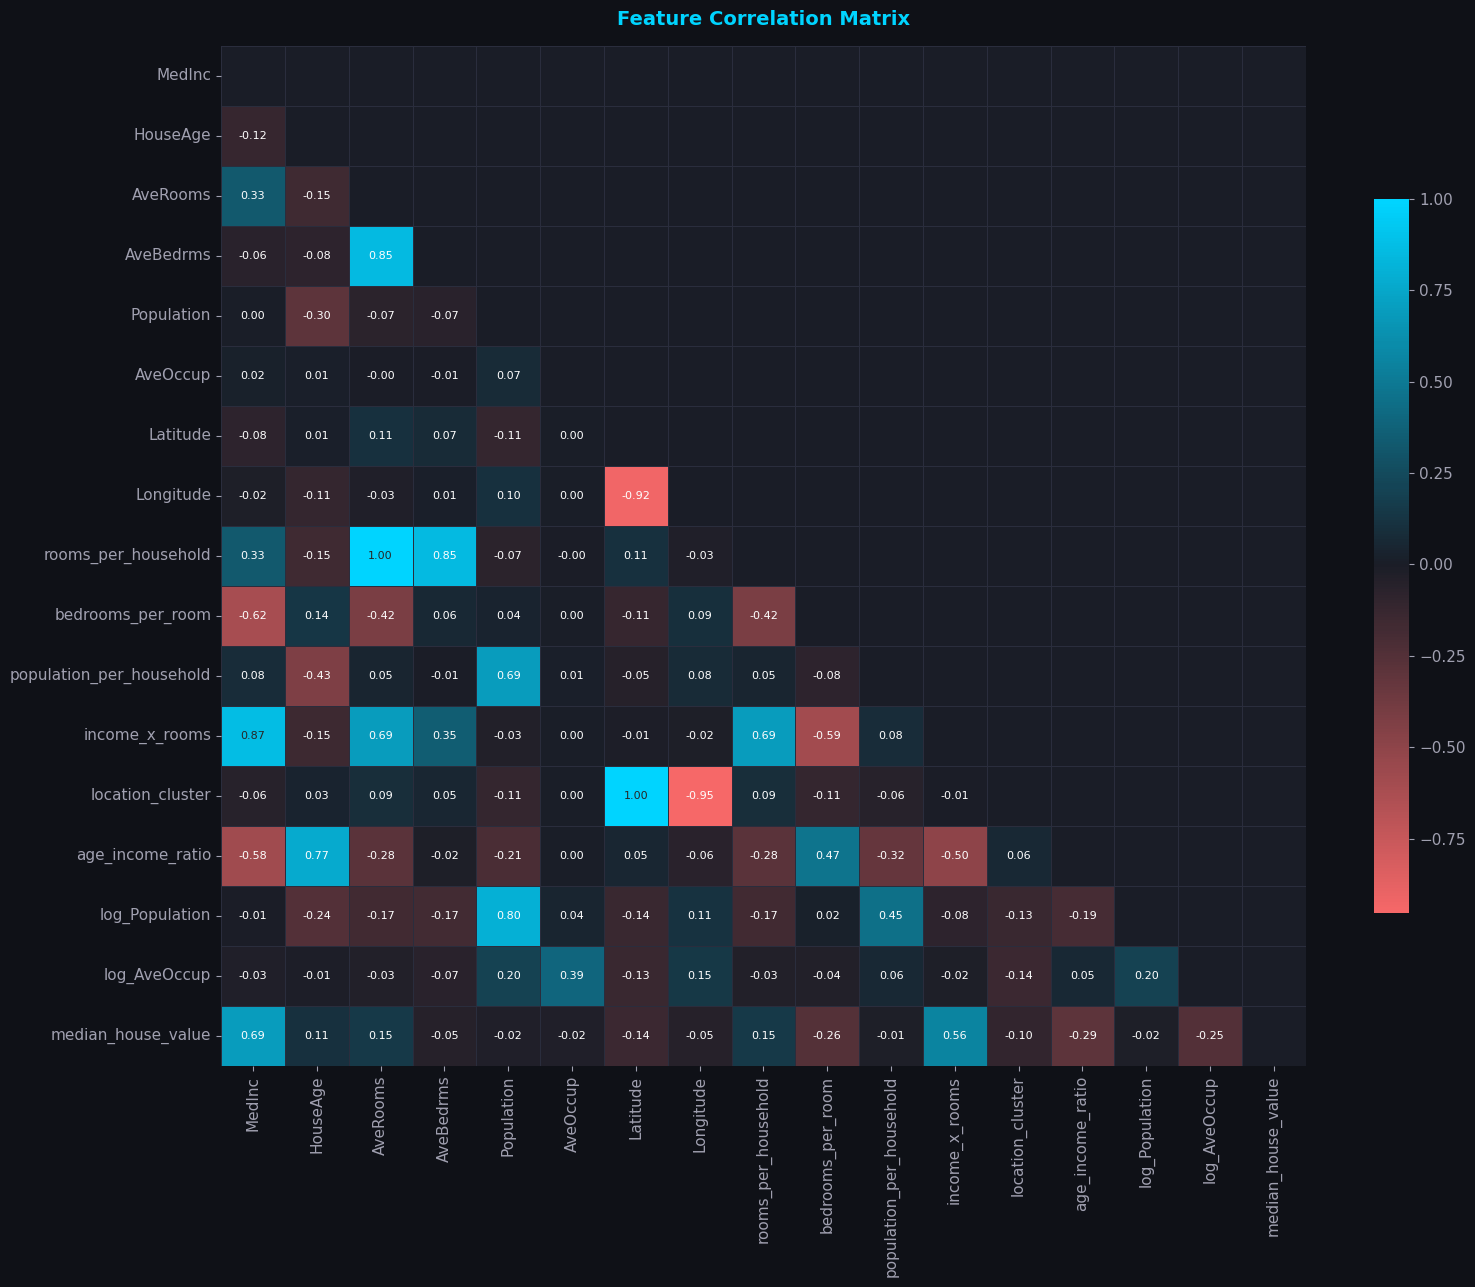

In [ ]:
# ── Correlation heatmap ──
corr = df[FEATURE_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = LinearSegmentedColormap.from_list('custom', ['#ff6b6b', '#1a1d27', '#00d4ff'])
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='#2a2d3d',
    ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, color=ACCENT, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

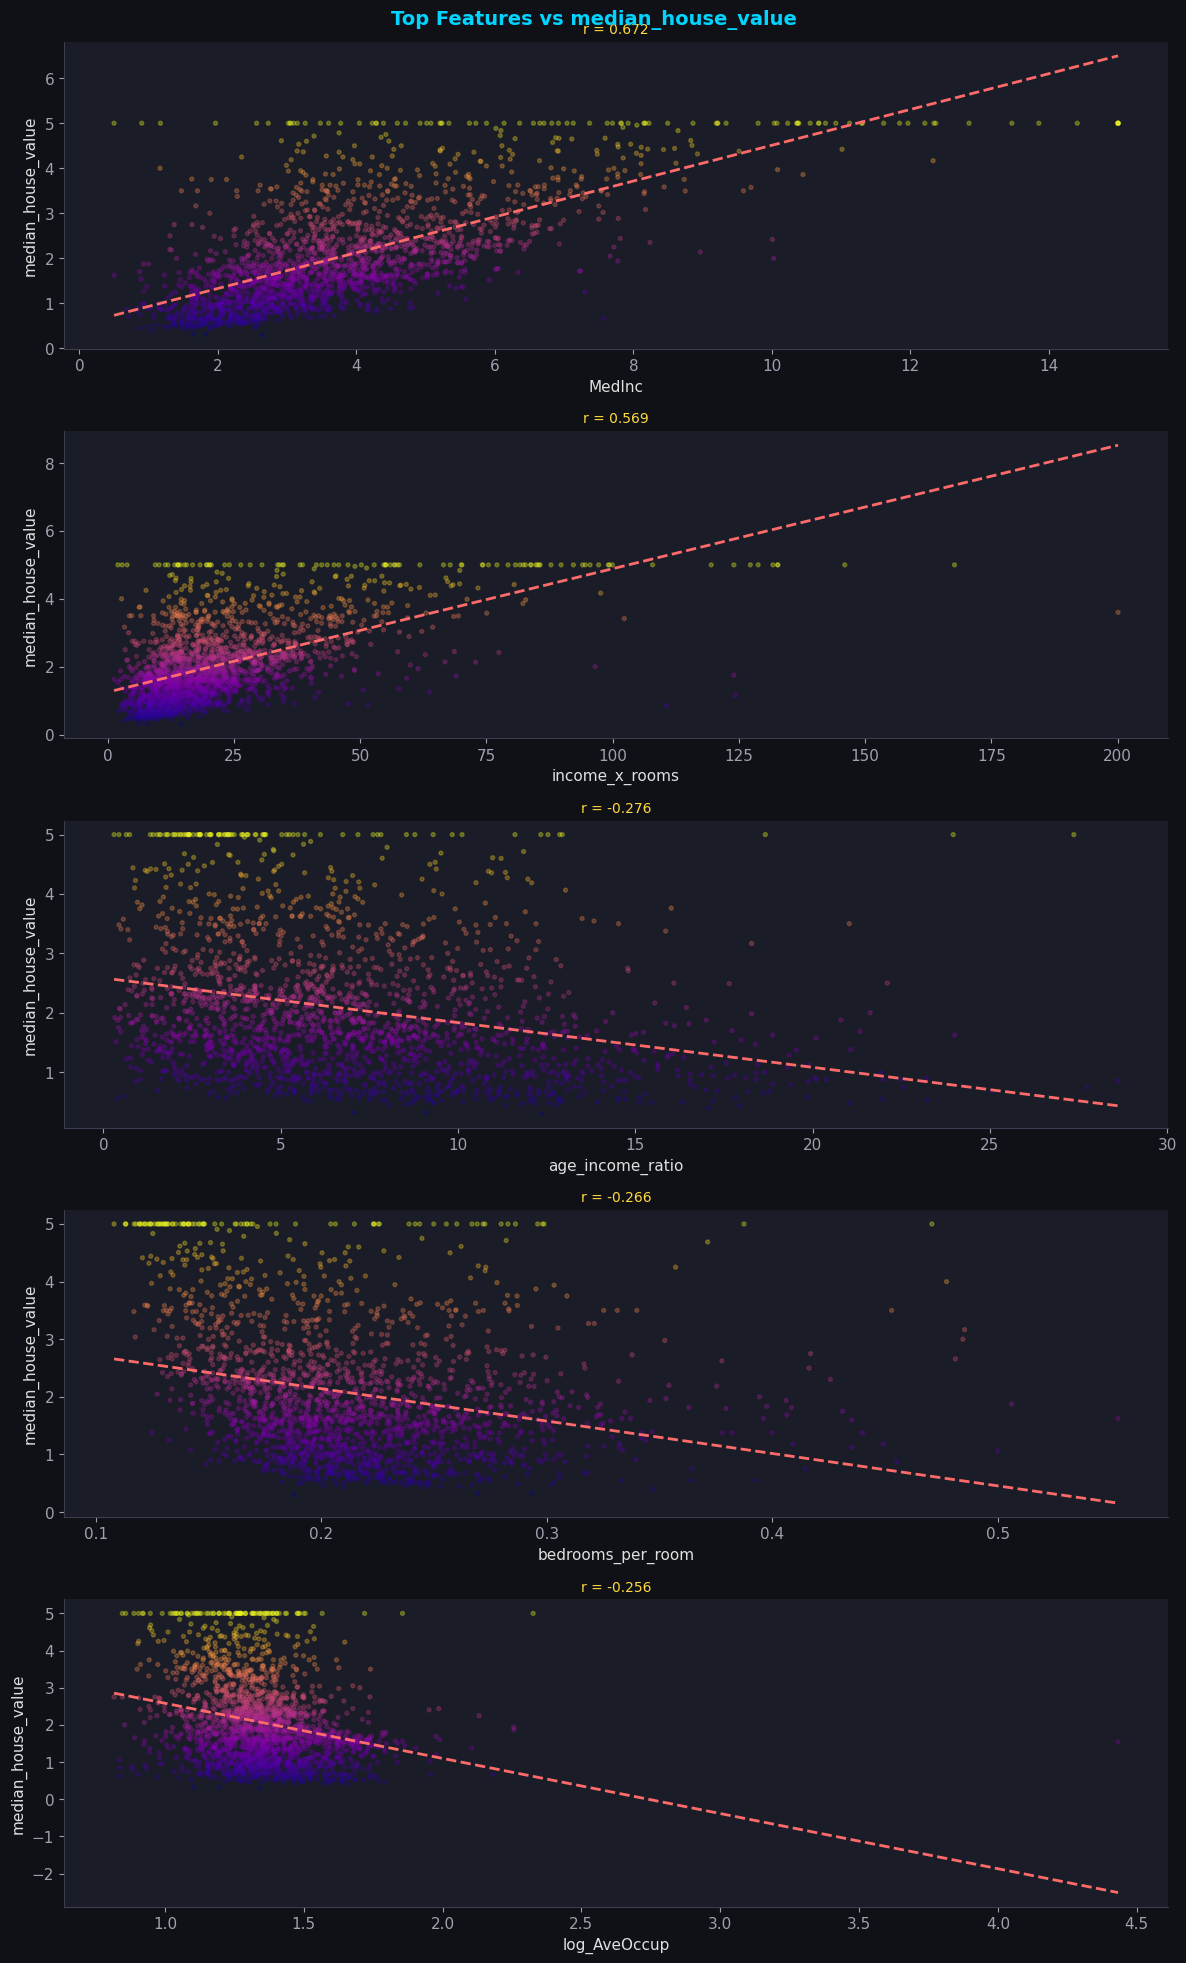

In [ ]:
# ── Scatter matrix for top correlated features ──
top_features = corr[TARGET].abs().sort_values(ascending=False).index[1:6].tolist()
plot_df = df[top_features + [TARGET]].sample(2000, random_state=SEED)

fig, axes = plt.subplots(len(top_features), 1, figsize=(12, 4*len(top_features)))
fig.suptitle(f'Top Features vs {TARGET}', fontsize=14, color=ACCENT, fontweight='bold')

for ax, feat in zip(axes, top_features):
    sc = ax.scatter(plot_df[feat], plot_df[TARGET],
                    alpha=0.3, s=8, c=plot_df[TARGET], cmap='plasma')
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET)
    # Trend line
    z = np.polyfit(plot_df[feat], plot_df[TARGET], 1)
    p = np.poly1d(z)
    xline = np.linspace(plot_df[feat].min(), plot_df[feat].max(), 100)
    ax.plot(xline, p(xline), color=ACCENT2, lw=2, linestyle='--')
    r = plot_df[[feat, TARGET]].corr().iloc[0,1]
    ax.set_title(f'r = {r:.3f}', color=ACCENT3, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = RobustScaler()  # robust to outliers
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Target range: ${y.min()*100_000:,.0f} — ${y.max()*100_000:,.0f}')

Train: (16512, 16)  |  Test: (4128, 16)
Target range: $14,999 — $500,001


In [ ]:
MODELS = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=15,
        min_samples_leaf=3, n_jobs=-1, random_state=SEED
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, subsample=0.8, random_state=SEED
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400, learning_rate=0.04,
        max_depth=6, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbosity=0
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.04,
        max_depth=6, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbose=-1
    ),
}

results = {}
trained = {}

for name, model in MODELS.items():
    print(f'⏳  Training {name}...', end=' ')
    model.fit(X_train_sc, y_train)   # use scaled features
    preds = model.predict(X_test_sc)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'preds': preds}
    trained[name] = model
    print(f'R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')

print('\n✅ All models trained')

⏳  Training Random Forest... R²=0.8028  RMSE=0.5084  MAE=0.3310
⏳  Training Gradient Boosting... R²=0.8275  RMSE=0.4754  MAE=0.3152
⏳  Training XGBoost... R²=0.8434  RMSE=0.4530  MAE=0.2998
⏳  Training LightGBM... R²=0.8409  RMSE=0.4566  MAE=0.3025

✅ All models trained


In [ ]:
# ── Metrics table ──
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != 'preds'}
    for name, vals in results.items()
}).T

# Dollar-scale RMSE & MAE (target was in $100k units)
metrics_df['RMSE_$'] = (metrics_df['RMSE'] * 100_000).map('${:,.0f}'.format)
metrics_df['MAE_$']  = (metrics_df['MAE']  * 100_000).map('${:,.0f}'.format)

display(HTML('<h4 style="color:#00d4ff">Model Comparison</h4>'))
display(metrics_df[['R²','RMSE_$','MAE_$']].style
    .background_gradient(subset=['R²'], cmap='Greens')
    .format({'R²': '{:.4f}'})
    .set_properties(**{'font-size': '13px'})
)

,R²,RMSE_$,MAE_$
Random Forest,0.8028,"$50,840","$33,102"
Gradient Boosting,0.8275,"$47,544","$31,523"
XGBoost,0.8434,"$45,297","$29,979"
LightGBM,0.8409,"$45,661","$30,255"


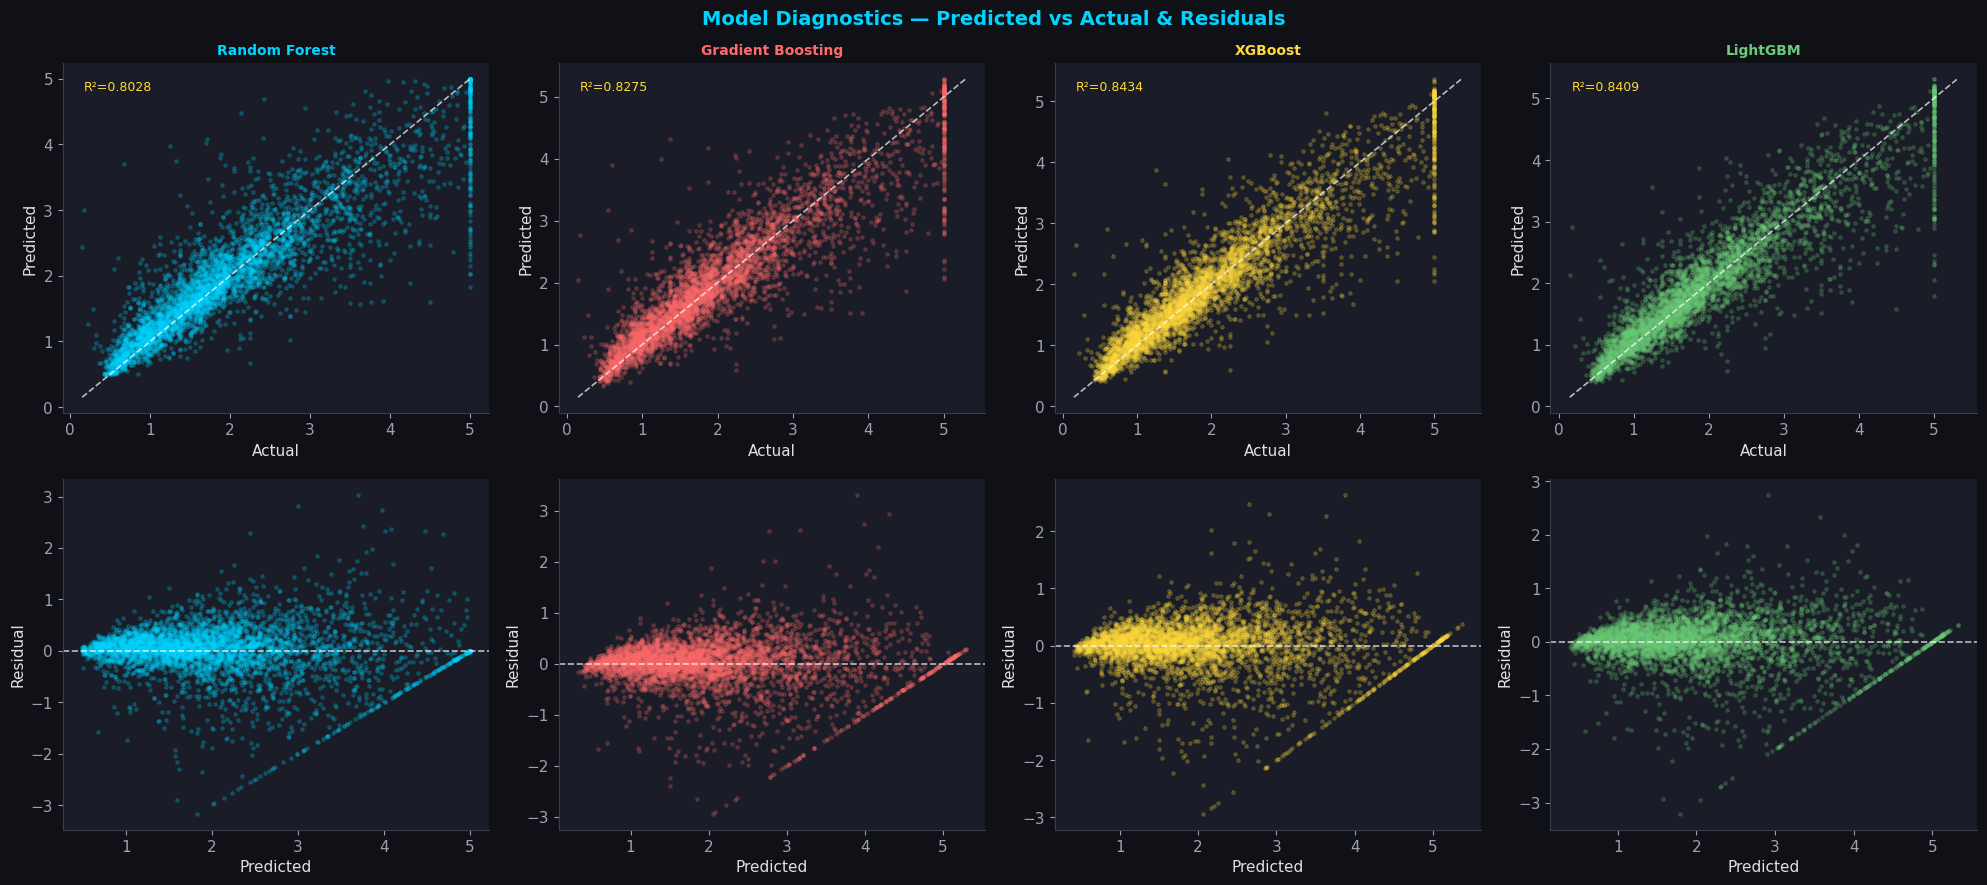

In [ ]:
# ── Predicted vs Actual + Residuals for each model ──
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Model Diagnostics — Predicted vs Actual & Residuals', fontsize=14,
             color=ACCENT, fontweight='bold')

for i, (name, vals) in enumerate(results.items()):
    preds = vals['preds']
    resid = preds - y_test
    lim = (min(y_test.min(), preds.min()), max(y_test.max(), preds.max()))
    color = PALETTE[i]

    # Pred vs Actual
    ax = axes[0, i]
    ax.scatter(y_test, preds, alpha=0.2, s=6, color=color)
    ax.plot(lim, lim, '--', color='white', lw=1.2, alpha=0.7)
    ax.set_title(name, color=color, fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.text(0.05, 0.92, f"R²={vals['R²']:.4f}", transform=ax.transAxes,
            color=ACCENT3, fontsize=9)

    # Residuals
    ax = axes[1, i]
    ax.scatter(preds, resid, alpha=0.2, s=6, color=color)
    ax.axhline(0, color='white', lw=1.2, linestyle='--', alpha=0.7)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()

5-Fold Cross-Validation R² (on training set):

  Random Forest          ████████████████████████████████  0.8019 ± 0.0066
  Gradient Boosting      █████████████████████████████████  0.8333 ± 0.0044
  XGBoost                █████████████████████████████████  0.8422 ± 0.0052
  LightGBM               █████████████████████████████████  0.8408 ± 0.0056


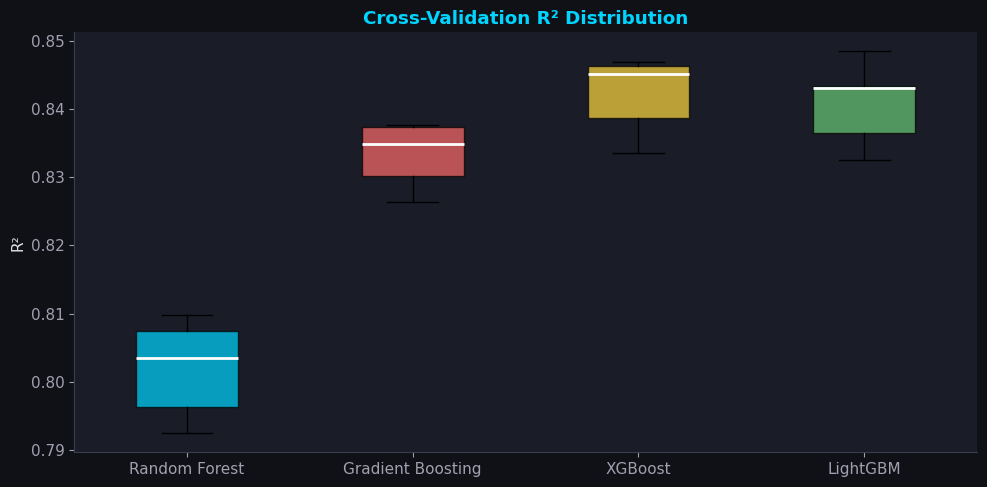

In [28]:
# ── Cross-validation ──
print('5-Fold Cross-Validation R² (on training set):\n')
cv_results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model in trained.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    bar = '█' * int(scores.mean() * 40)
    print(f'  {name:<22} {bar}  {scores.mean():.4f} ± {scores.std():.4f}')

# Box plot
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    cv_results.values(),
    labels=cv_results.keys(),
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2},
)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Cross-Validation R² Distribution', color=ACCENT, fontweight='bold')
ax.set_ylabel('R²')
plt.tight_layout()
plt.show()

In [29]:
# ── Pick model to explain ──
EXPLAIN_MODEL = 'XGBoost'   # ← change to 'Random Forest', 'LightGBM', etc.

model_to_explain = trained[EXPLAIN_MODEL]

# Sample for speed
N_BACKGROUND = 500
N_EXPLAIN    = 1000
rng = np.random.default_rng(SEED)

bg_idx  = rng.choice(len(X_train_sc), N_BACKGROUND, replace=False)
exp_idx = rng.choice(len(X_test_sc),  N_EXPLAIN,    replace=False)

X_bg  = X_train_sc[bg_idx]
X_exp = X_test_sc[exp_idx]
y_exp = y_test.iloc[exp_idx].values

print(f'Computing SHAP values for {EXPLAIN_MODEL} on {N_EXPLAIN} samples...')
explainer   = shap.TreeExplainer(model_to_explain, X_bg)
shap_values = explainer.shap_values(X_exp)
print(f'✅ SHAP values shape: {shap_values.shape}')

Computing SHAP values for XGBoost on 1000 samples...


 98%|===================| 976/1000 [00:29<00:00]       

✅ SHAP values shape: (1000, 16)


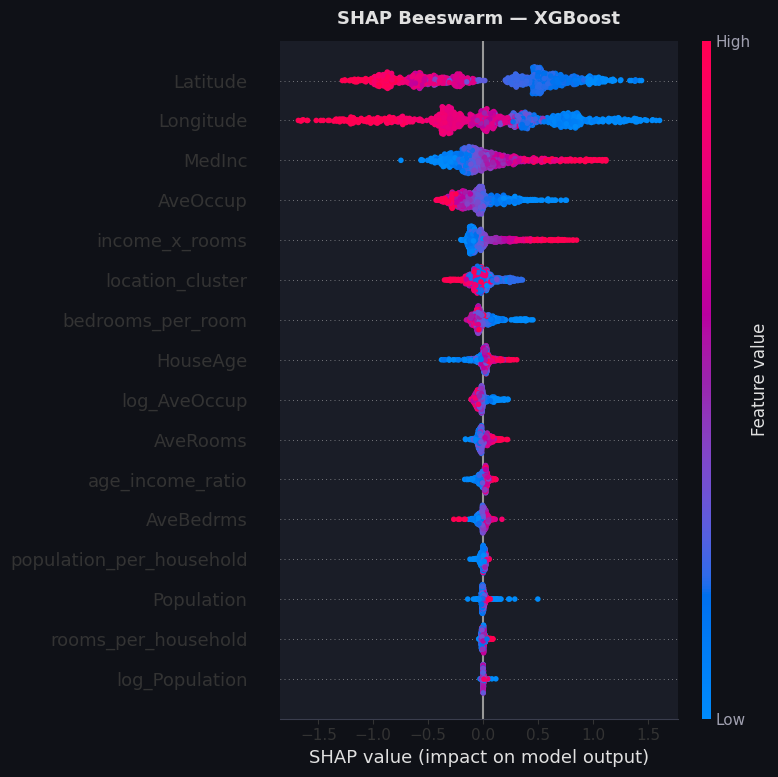

In [ ]:
# ── 7a. SHAP Summary Beeswarm ──
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_exp, feature_names=FEATURE_COLS, show=False)
plt.title(f'SHAP Beeswarm — {EXPLAIN_MODEL}', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

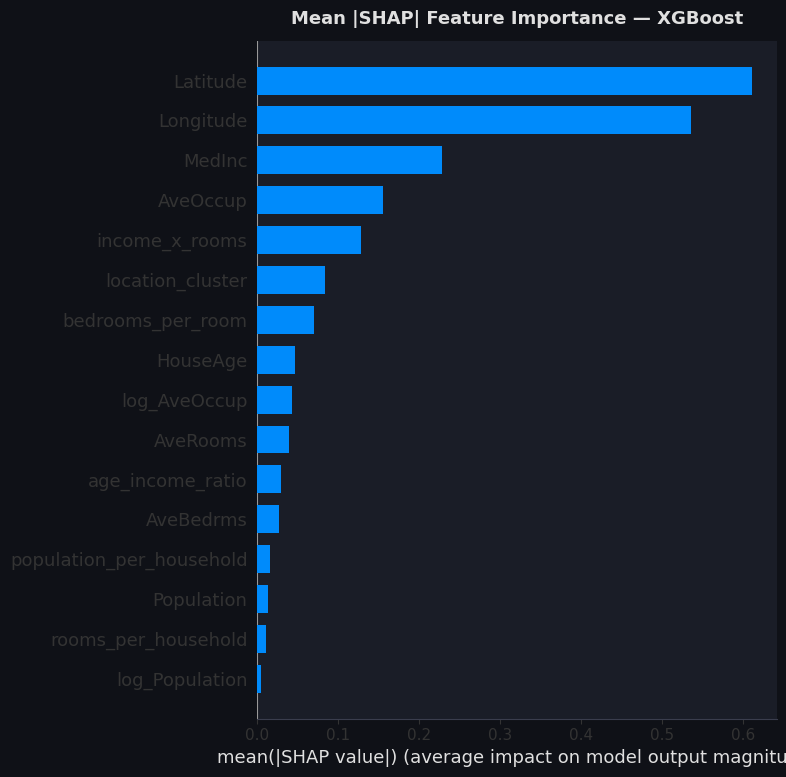

In [31]:
# ── 7b. SHAP Bar (Mean |SHAP|) ──
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_exp, feature_names=FEATURE_COLS,
                  plot_type='bar', show=False)
plt.title(f'Mean |SHAP| Feature Importance — {EXPLAIN_MODEL}',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

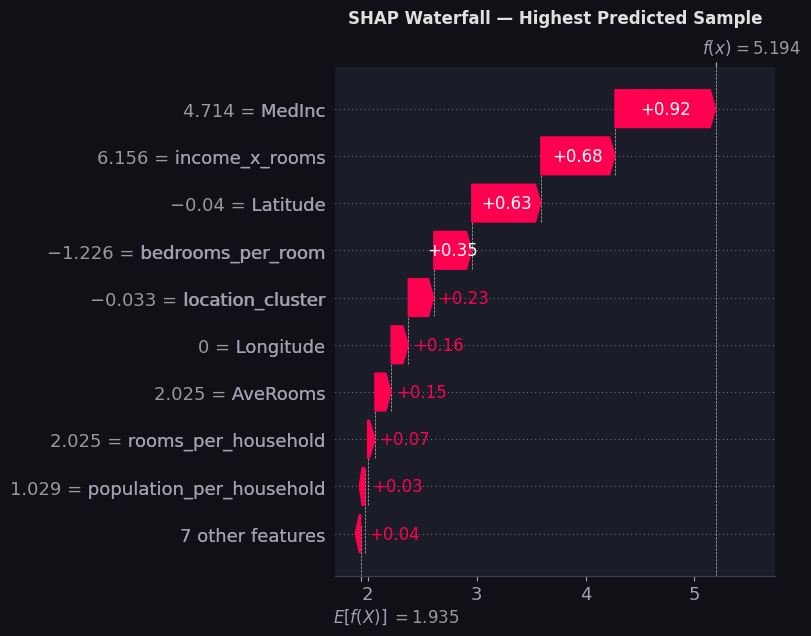

In [32]:
# ── 7c. SHAP Waterfall — highest predicted price sample ──
best_idx = np.argmax(model_to_explain.predict(X_exp))

plt.figure(figsize=(11, 6))
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[best_idx],
        base_values = explainer.expected_value,
        data        = X_exp[best_idx],
        feature_names = FEATURE_COLS
    ),
    show=False
)
plt.title('SHAP Waterfall — Highest Predicted Sample', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [33]:
# ── 7d. Interactive SHAP Force Plot (JS) ──
# Shows a single prediction with interactive hover
shap.force_plot(
    explainer.expected_value,
    shap_values[best_idx],
    X_exp[best_idx],
    feature_names=FEATURE_COLS
)

In [34]:
# ── 7e. SHAP Force Plot — multiple samples (interactive scroll) ──
shap.force_plot(
    explainer.expected_value,
    shap_values[:200],
    X_exp[:200],
    feature_names=FEATURE_COLS
)

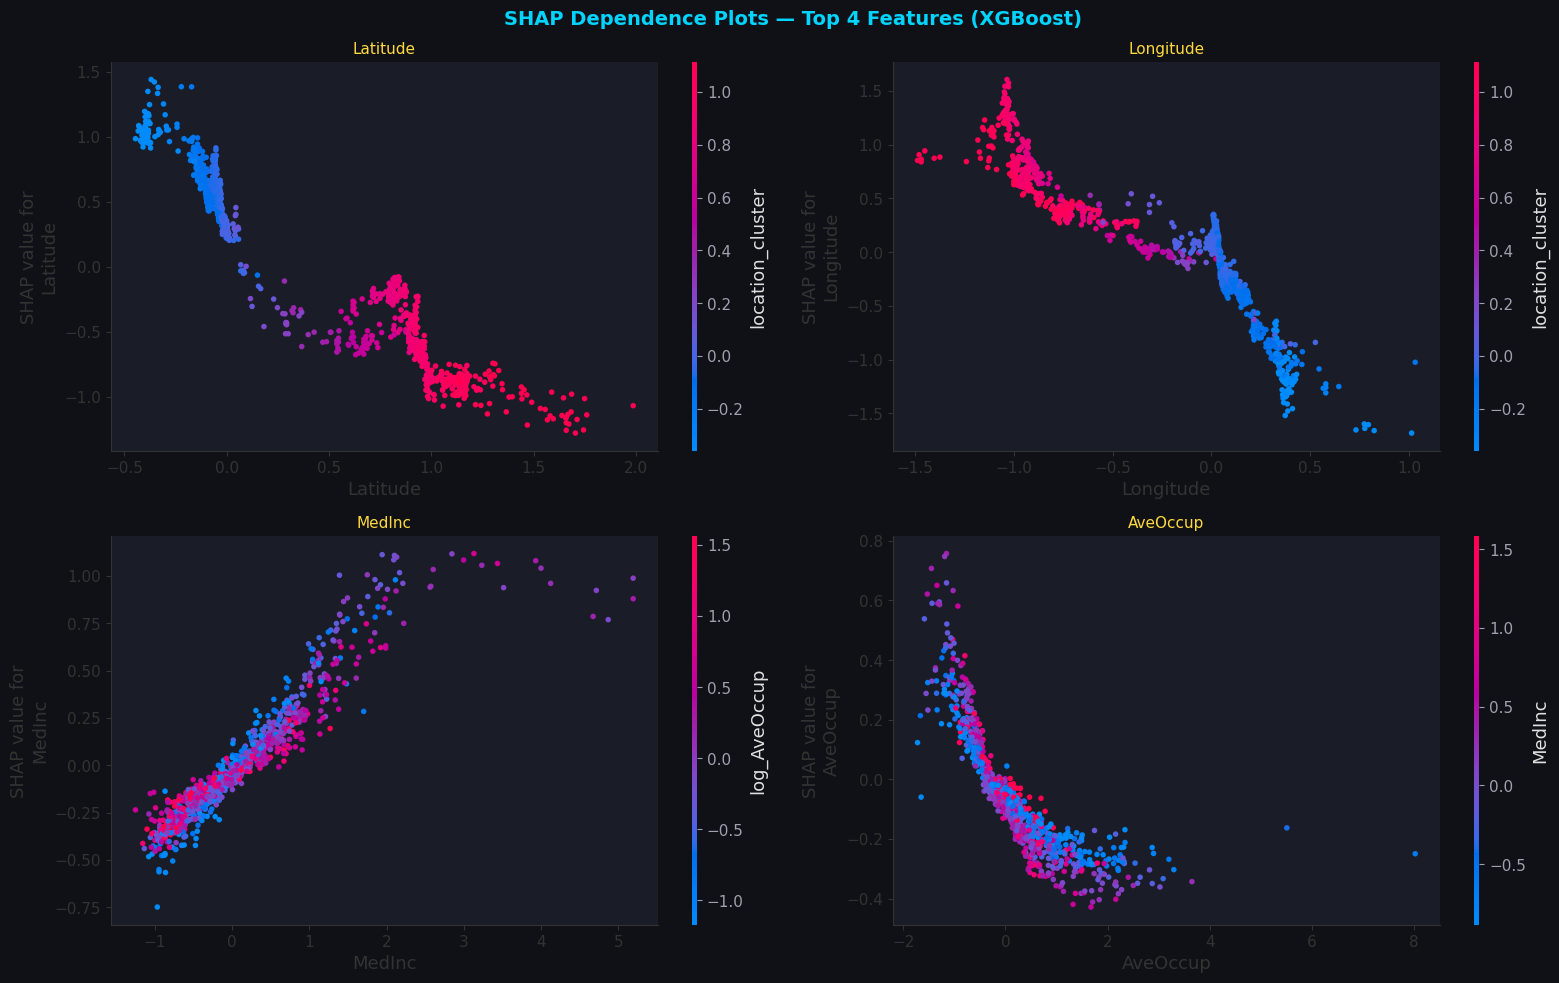

In [35]:
# ── 7f. SHAP Dependence Plots — top 4 features ──
shap_abs_mean = np.abs(shap_values).mean(axis=0)
top4_idx = np.argsort(shap_abs_mean)[::-1][:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'SHAP Dependence Plots — Top 4 Features ({EXPLAIN_MODEL})',
             fontsize=14, color=ACCENT, fontweight='bold')

for ax, fi in zip(axes.flat, top4_idx):
    shap.dependence_plot(fi, shap_values, X_exp,
                         feature_names=FEATURE_COLS, ax=ax, show=False)
    ax.set_title(FEATURE_COLS[fi], color=ACCENT3, fontsize=11)

plt.tight_layout()
plt.show()

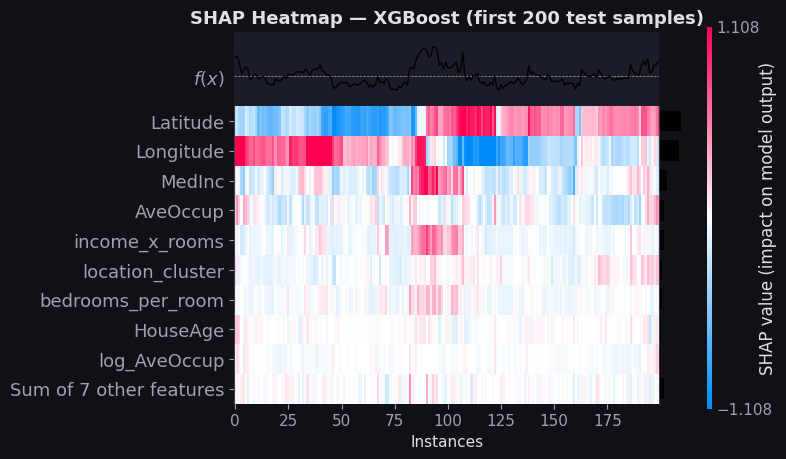

In [36]:
# ── 7g. SHAP Heatmap ──
plt.figure(figsize=(14, 8))
shap.plots.heatmap(
    shap.Explanation(
        values        = shap_values[:200],
        base_values   = np.full(200, explainer.expected_value),
        data          = X_exp[:200],
        feature_names = FEATURE_COLS
    ),
    show=False
)
plt.title(f'SHAP Heatmap — {EXPLAIN_MODEL} (first 200 test samples)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

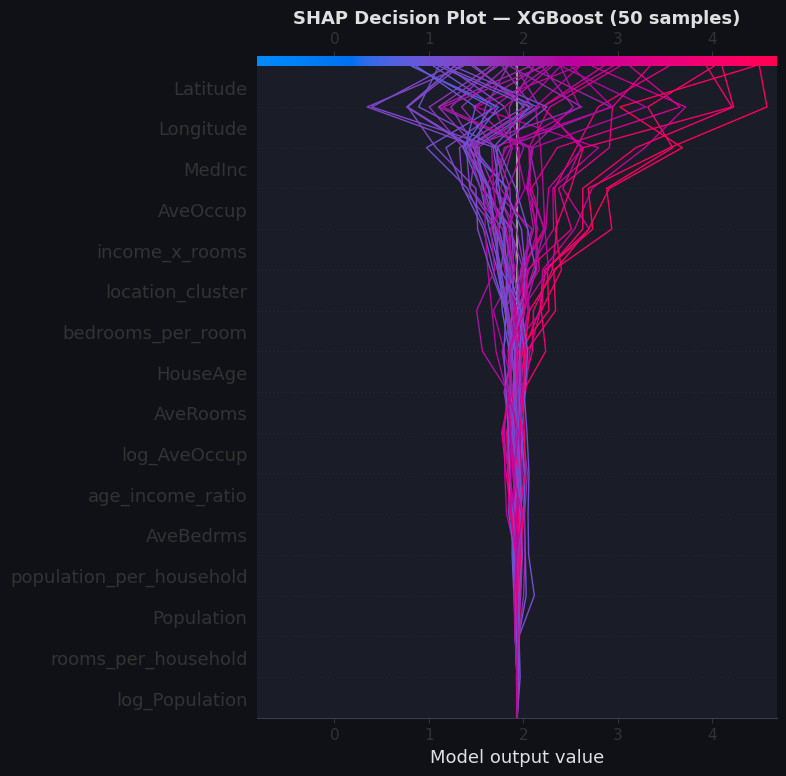

In [37]:
# ── 7h. SHAP Decision Plot ──
plt.figure(figsize=(12, 8))
shap.decision_plot(
    explainer.expected_value,
    shap_values[:50],
    feature_names=FEATURE_COLS,
    show=False
)
plt.title(f'SHAP Decision Plot — {EXPLAIN_MODEL} (50 samples)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

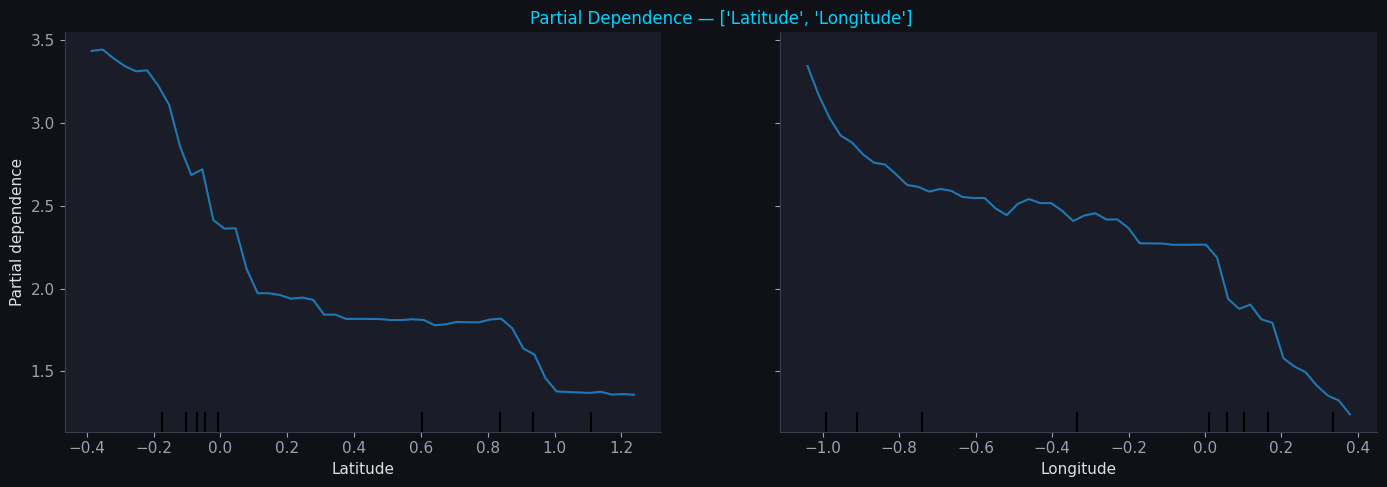

In [38]:
# ── 7i. Partial Dependence Plots (sklearn) ──
top2_names = [FEATURE_COLS[i] for i in top4_idx[:2]]

fig, ax = plt.subplots(figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    model_to_explain, X_test_sc,
    features=[FEATURE_COLS.index(f) for f in top2_names],
    feature_names=FEATURE_COLS,
    ax=ax, grid_resolution=50, random_state=SEED
)
ax.set_title(f'Partial Dependence — {top2_names}', color=ACCENT, fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
# ── Build widgets ──
style  = {'description_width': '200px'}
layout = widgets.Layout(width='520px')

w_income   = widgets.FloatSlider(value=5.0,  min=0.5,  max=15.0, step=0.1,  description='Median Income ($10k)', style=style, layout=layout)
w_age      = widgets.FloatSlider(value=20.0, min=1.0,  max=52.0, step=1.0,  description='House Age (years)',    style=style, layout=layout)
w_rooms    = widgets.FloatSlider(value=5.0,  min=1.0,  max=15.0, step=0.5,  description='Avg Rooms',           style=style, layout=layout)
w_bedrms   = widgets.FloatSlider(value=1.0,  min=0.5,  max=5.0,  step=0.1,  description='Avg Bedrooms',        style=style, layout=layout)
w_pop      = widgets.FloatSlider(value=1200, min=50,   max=5000, step=50,   description='Population (block)',  style=style, layout=layout)
w_occup    = widgets.FloatSlider(value=2.5,  min=1.0,  max=10.0, step=0.1,  description='Avg Occupancy',       style=style, layout=layout)
w_lat      = widgets.FloatSlider(value=34.0, min=32.5, max=42.0, step=0.1,  description='Latitude',            style=style, layout=layout)
w_lon      = widgets.FloatSlider(value=-118, min=-124, max=-114, step=0.1,  description='Longitude',           style=style, layout=layout)
w_model    = widgets.Dropdown(options=list(trained.keys()), value=EXPLAIN_MODEL,
                               description='Model', style=style, layout=layout)
btn        = widgets.Button(description='🔮  Predict & Explain',
                             button_style='info',
                             layout=widgets.Layout(width='240px', height='40px'))
out        = widgets.Output()

def on_predict(b):
    with out:
        clear_output(wait=True)

        # Build a single row matching FEATURE_COLS
        medinc  = w_income.value
        age     = w_age.value
        rooms   = w_rooms.value
        bedrms  = w_bedrms.value
        pop     = w_pop.value
        occup   = w_occup.value
        lat     = w_lat.value
        lon     = w_lon.value

        row_dict = {
            'MedInc':    medinc,
            'HouseAge':  age,
            'AveRooms':  rooms,
            'AveBedrms': bedrms,
            'Population': pop,
            'AveOccup':  occup,
            'Latitude':  lat,
            'Longitude': lon,
        }
        # engineered
        row_dict['rooms_per_household']      = rooms
        row_dict['bedrooms_per_room']        = bedrms / max(rooms, 0.01)
        row_dict['population_per_household'] = pop / max(age, 0.01)
        row_dict['income_x_rooms']           = medinc * rooms
        row_dict['location_cluster']         = abs(lat * lon)
        row_dict['age_income_ratio']         = age / (medinc + 1)
        row_dict['log_Population']           = np.log1p(pop)
        row_dict['log_AveOccup']             = np.log1p(occup)

        row = pd.DataFrame([row_dict])[FEATURE_COLS]
        row_sc = scaler.transform(row)

        chosen_model = trained[w_model.value]
        pred_raw     = chosen_model.predict(row_sc)[0]
        pred_dollar  = pred_raw * 100_000

        # SHAP for this row
        exp_local  = shap.TreeExplainer(chosen_model, X_bg)
        sv_local   = exp_local.shap_values(row_sc)[0]
        base       = exp_local.expected_value * 100_000

        top_drivers = sorted(
            zip(FEATURE_COLS, sv_local * 100_000),
            key=lambda x: abs(x[1]), reverse=True
)[:6]

        # ── Print result ──
        display(HTML(f"""
        <div style="background:#1a1d27;border:1px solid #00d4ff;border-radius:10px;
                    padding:20px;font-family:monospace;color:#e0e0e0;">
          <h3 style="color:#00d4ff;margin-top:0">🏠 Prediction Result — {w_model.value}</h3>
          <p style="font-size:24px;color:#ffd93d;font-weight:bold;">
            Estimated Value: <span style="color:#6bcb77">${pred_dollar:,.0f}</span>
          </p>
          <p style="color:#a0a0b0">Base (avg) value: ${base:,.0f}</p>
          <hr style="border-color:#3a3d4d">
          <h4 style="color:#ffd93d">Top SHAP Drivers:</h4>
          {''.join([
            f'<p>{"↑" if v>0 else "↓"} <b>{f}</b>: '
            f'<span style="color:{"#6bcb77" if v>0 else "#ff6b6b"}">{"+ " if v>0 else ""}{v:,.0f}$</span></p>'
            for f, v in top_drivers
          ])}
        </div>
        """))

        # ── SHAP waterfall for this prediction ──
        plt.figure(figsize=(11, 5))
        shap.waterfall_plot(
            shap.Explanation(
                values        = sv_local,
                base_values   = exp_local.expected_value,
                data          = row_sc[0],
                feature_names = FEATURE_COLS
            ),
            show=False
        )
        plt.title(f'Your House — SHAP Explanation ({w_model.value})',
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # ── Force plot ──
        display(shap.force_plot(
            exp_local.expected_value, sv_local, row_sc[0],
            feature_names=FEATURE_COLS
        ))

btn.on_click(on_predict)

display(HTML('<h3 style="color:#00d4ff">🎛️ Configure Your House</h3>'))
display(widgets.VBox([
    w_model, w_income, w_age, w_rooms, w_bedrms,
    w_pop, w_occup, w_lat, w_lon, btn
]))
display(out)

Output()

,Mean Err,Median Err,Std Err,Count
bucket,,,,
<$100k,"$20,299","$13,627","$24,378","73,900,000"
$100-200k,"$22,786","$16,353","$23,184","168,200,000"
$200-300k,"$31,172","$22,312","$28,854","95,600,000"
$300-400k,"$46,232","$33,555","$41,764","41,200,000"
$400-500k,"$62,109","$49,833","$50,493","16,000,000"
>$500k,"$65,045","$36,165","$69,051","17,900,000"


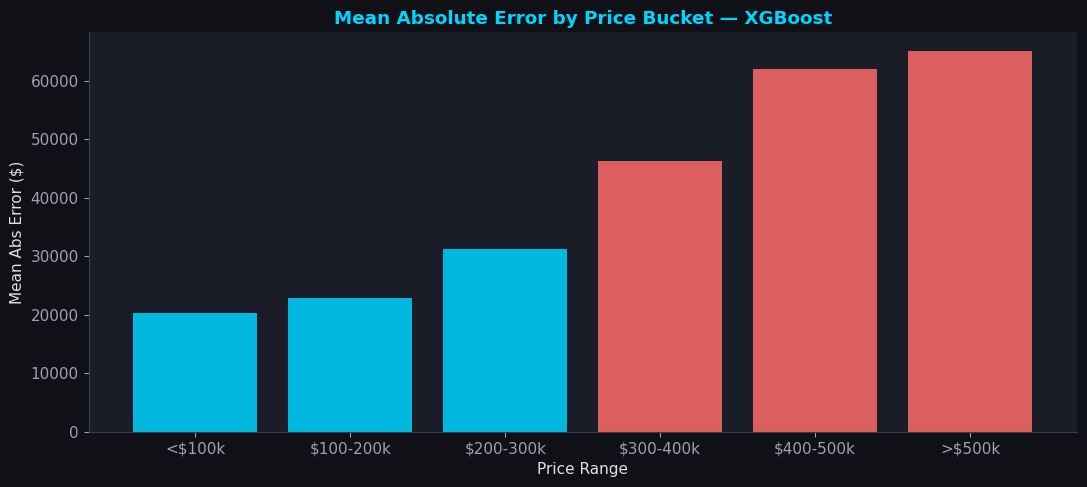

In [40]:
# Use best model
best_name  = metrics_df['R²'].astype(float).idxmax()
best_preds = results[best_name]['preds']
errors     = np.abs(best_preds - y_test.values)

# Bucket by price range
bins   = [0, 1, 2, 3, 4, 5, np.inf]
labels = ['<$100k','$100-200k','$200-300k','$300-400k','$400-500k','>$500k']
bucket = pd.cut(y_test, bins=bins, labels=labels)

err_df = pd.DataFrame({'error': errors, 'bucket': bucket.values})
grouped = err_df.groupby('bucket')['error'].agg(['mean','median','std','count'])
grouped.columns = ['Mean Err','Median Err','Std Err','Count']
grouped *= 100_000  # back to dollars
grouped['Count'] = grouped['Count'].astype(int)

display(HTML(f'<h4 style="color:#00d4ff">Error Analysis by Price Bucket — {best_name}</h4>'))
display(grouped.style
    .background_gradient(subset=['Mean Err'], cmap='Reds')
    .format({'Mean Err': '${:,.0f}', 'Median Err': '${:,.0f}',
             'Std Err': '${:,.0f}', 'Count': '{:,}'})
)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [ACCENT if v < grouped['Mean Err'].median() else ACCENT2
          for v in grouped['Mean Err']]
ax.bar(grouped.index.astype(str), grouped['Mean Err'], color=colors, alpha=0.85, edgecolor='none')
ax.set_title(f'Mean Absolute Error by Price Bucket — {best_name}',
             color=ACCENT, fontweight='bold')
ax.set_ylabel('Mean Abs Error ($)')
ax.set_xlabel('Price Range')
plt.tight_layout()
plt.show()